In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

ANALYTICS_DIR = "/content/drive/MyDrive/zepto-data-ai-platform/analytics"

TITANIC_PATH = f"{ANALYTICS_DIR}/titanic.csv"

# IMPORTANT:
# We are NOT using sns.load_dataset() again.
df = pd.read_csv(TITANIC_PATH)

print("Dataset loaded from saved CSV.")
print("Shape:", df.shape)

df.head()

Mounted at /content/drive
Dataset loaded from saved CSV.
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
!pip install -q scikit-learn imbalanced-learn joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.base import clone

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

In [4]:
FEATURES = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

TARGET = "survived"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("CLASS COUNTS")
print(y.value_counts())

print("\nCLASS PERCENTAGES")
print((y.value_counts(normalize=True) * 100).round(2))


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTrain class balance:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class balance:")
print((y_test.value_counts(normalize=True) * 100).round(2))

CLASS COUNTS
survived
0    549
1    342
Name: count, dtype: int64

CLASS PERCENTAGES
survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Training rows: 712
Testing rows: 179

Train class balance:
survived
0    61.66
1    38.34
Name: proportion, dtype: float64

Test class balance:
survived
0    61.45
1    38.55
Name: proportion, dtype: float64


### Why Stratified Splitting Was Used

The survived and not-survived classes are not perfectly balanced. A stratified
train/test split preserves approximately the same class proportions in both
sets. This makes the evaluation more representative and prevents accidental
class imbalance caused by random splitting.

In [6]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created.")
print("It will be fitted ONLY on training data.")

Preprocessor created.
It will be fitted ONLY on training data.


In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}


pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model)
        ]
    )

print("Three complete ML pipelines created.")

Three complete ML pipelines created.


In [9]:
results = []
fitted_models = {}
prediction_store = {}

for name, pipeline in pipelines.items():

    print("\nTraining:", name)

    # Fits preprocessing + model using TRAINING DATA ONLY
    pipeline.fit(X_train, y_train)

    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    prediction_store[name] = {
        "prediction": y_pred,
        "probability": y_prob
    }


results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")
display(results_df.round(4))


Training: Logistic Regression

Training: Decision Tree

Training: Random Forest

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
1,Decision Tree,0.7933,0.8636,0.5507,0.6726,0.8292
2,Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300


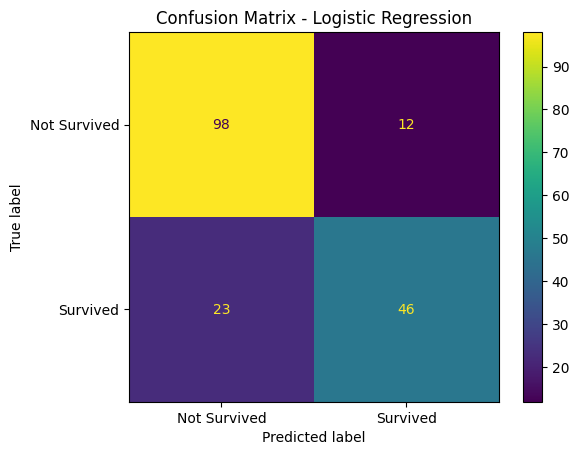

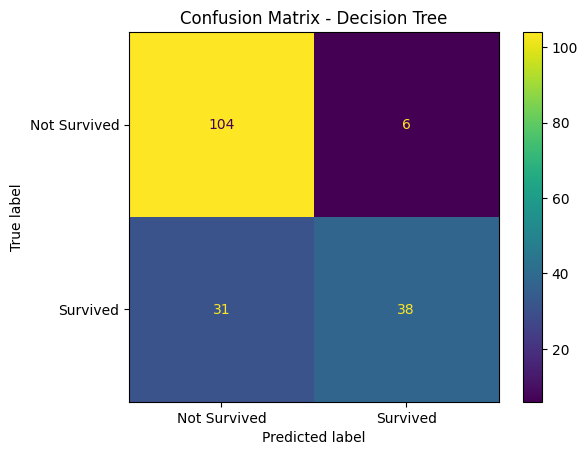

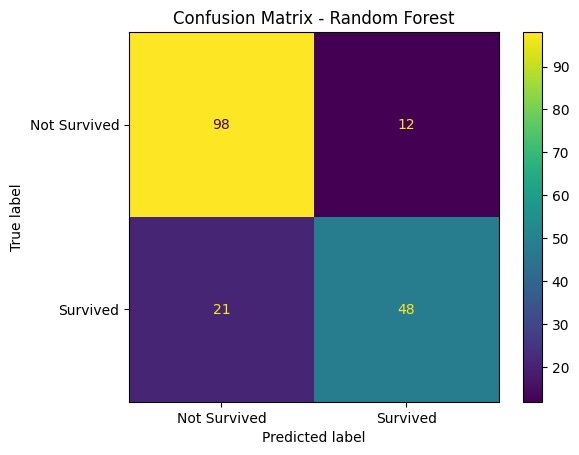

In [10]:
for name in fitted_models:

    y_pred = prediction_store[name]["prediction"]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Not Survived",
            "Survived"
        ]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

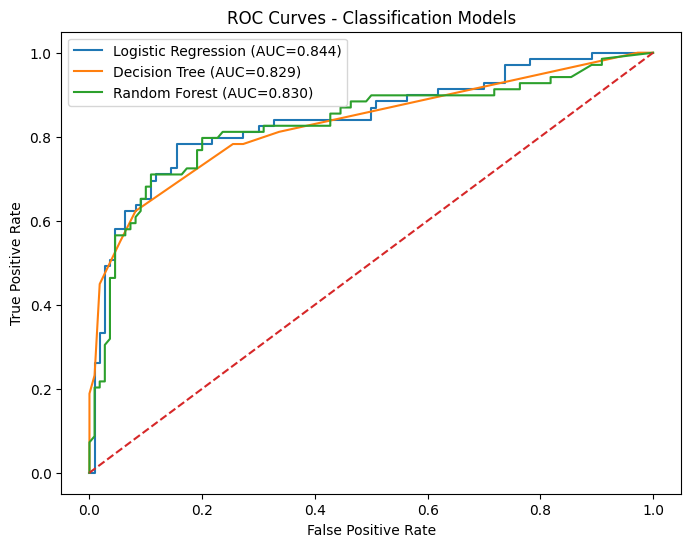

In [11]:
plt.figure(figsize=(8, 6))

for name in fitted_models:

    y_prob = prediction_store[name]["probability"]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Classification Models")
plt.legend()
plt.show()

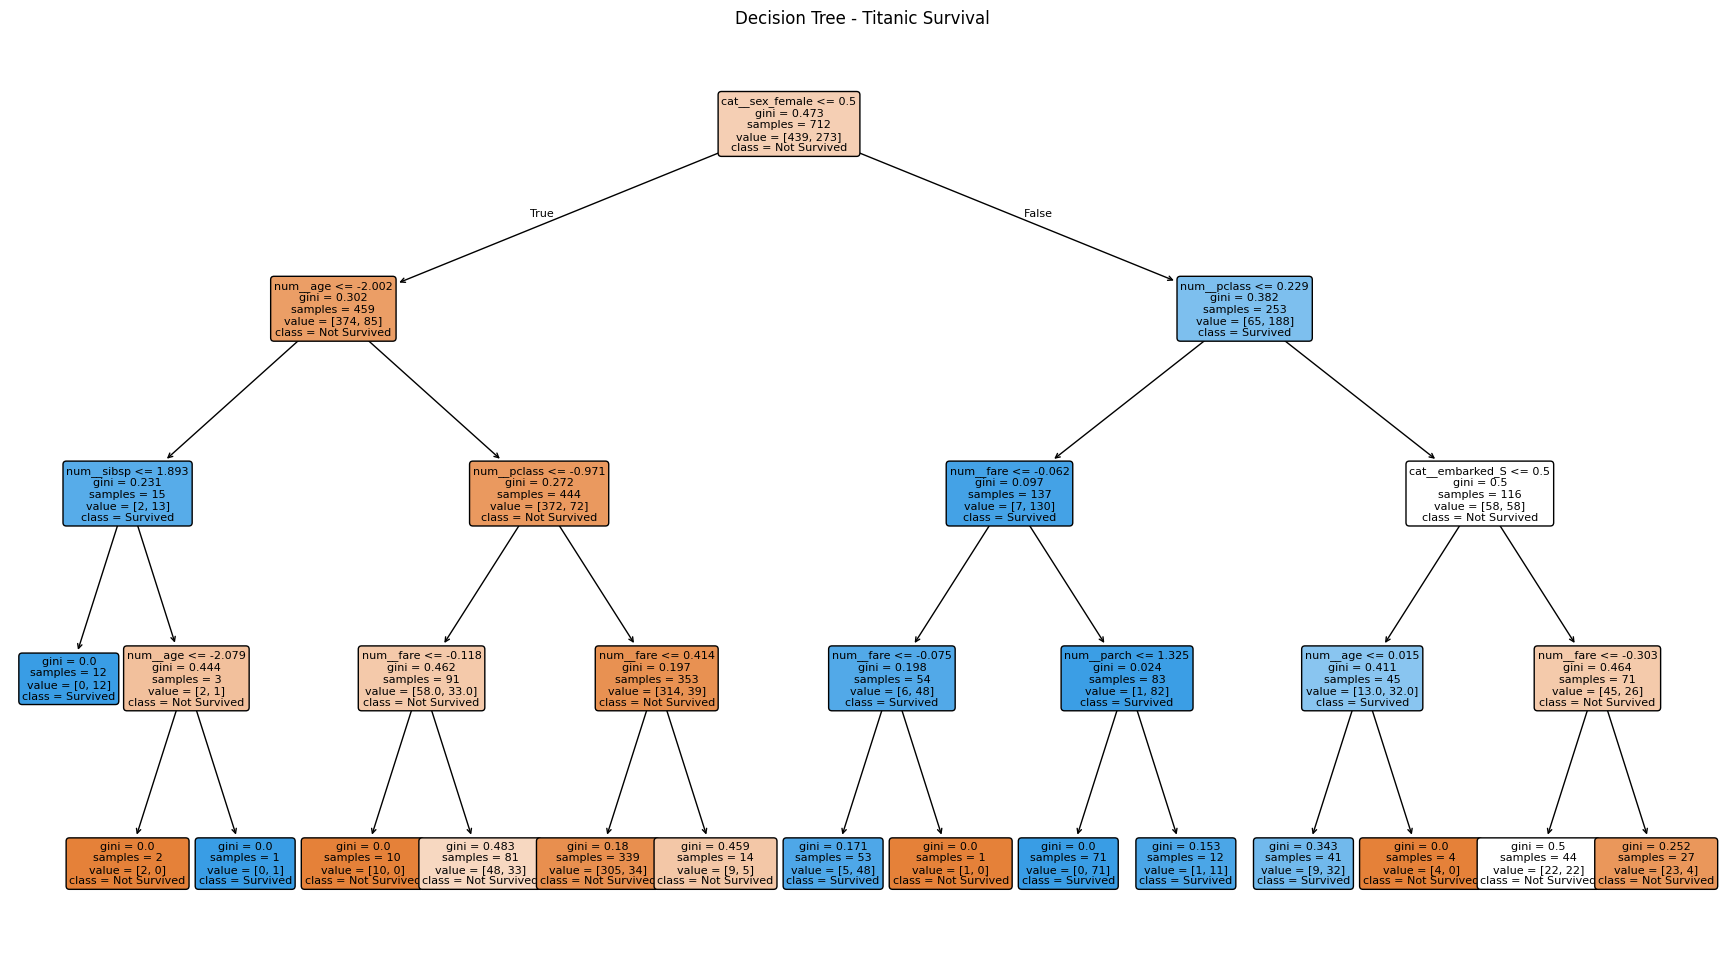

In [12]:
tree_pipeline = fitted_models[
    "Decision Tree"
]

tree_preprocessor = tree_pipeline.named_steps[
    "preprocessor"
]

tree_model = tree_pipeline.named_steps[
    "model"
]

feature_names = (
    tree_preprocessor
    .get_feature_names_out()
)

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Titanic Survival")

plt.show()

In [13]:
# -------------------------------
# A. BASELINE
# -------------------------------

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)


# -------------------------------
# B. CLASS WEIGHT = BALANCED
# -------------------------------

balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)


# -------------------------------
# C. SMOTE
# -------------------------------

smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),

        # SMOTE occurs only during training
        ("smote", SMOTE(
            random_state=42
        )),

        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)


imbalance_models = {
    "Baseline": baseline_pipeline,
    "Class Weight Balanced": balanced_pipeline,
    "SMOTE": smote_pipeline
}


imbalance_results = []

for name, model in imbalance_models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    imbalance_results.append({
        "Strategy": name,

        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })


imbalance_df = pd.DataFrame(
    imbalance_results
)

display(
    imbalance_df.round(4)
)

,Strategy,Precision,Recall,F1
0,Baseline,0.7931,0.6667,0.7244
1,Class Weight Balanced,0.7297,0.7826,0.7552
2,SMOTE,0.7397,0.7826,0.7606


In [14]:
best_imbalance = (
    imbalance_df
    .sort_values("F1", ascending=False)
    .iloc[0]
)

print(
    "Best imbalance strategy based on F1:",
    best_imbalance["Strategy"]
)

print(
    f"Precision = {best_imbalance['Precision']:.3f}"
)

print(
    f"Recall = {best_imbalance['Recall']:.3f}"
)

print(
    f"F1 = {best_imbalance['F1']:.3f}"
)

print(
    "\nConclusion: The strategy with the highest F1 score "
    "provides the strongest balance between precision and recall "
    "for this experiment."
)

Best imbalance strategy based on F1: SMOTE
Precision = 0.740
Recall = 0.783
F1 = 0.761

Conclusion: The strategy with the highest F1 score provides the strongest balance between precision and recall for this experiment.


In [15]:
rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),

        ("model", RandomForestClassifier(
            oob_score=True,
            random_state=42
        ))
    ]
)


param_grid = {
    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        None,
        5,
        10
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}


grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


grid_search.fit(
    X_train,
    y_train
)


print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(
    round(
        grid_search.best_score_,
        4
    )
)


best_rf_pipeline = grid_search.best_estimator_

best_rf_model = best_rf_pipeline.named_steps[
    "model"
]


print("\nOOB Score:")
print(
    round(
        best_rf_model.oob_score_,
        4
    )
)

Best Parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 100}

Best CV F1:
0.7459

OOB Score:
0.8272


In [16]:
rf_tuned_pred = best_rf_pipeline.predict(
    X_test
)

rf_tuned_prob = best_rf_pipeline.predict_proba(
    X_test
)[:, 1]


tuned_rf_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        rf_tuned_pred
    ),

    "Precision": precision_score(
        y_test,
        rf_tuned_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        rf_tuned_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        rf_tuned_pred,
        zero_division=0
    ),

    "AUC": roc_auc_score(
        y_test,
        rf_tuned_prob
    )
}


print("TUNED RANDOM FOREST TEST METRICS")

for metric, value in tuned_rf_metrics.items():
    print(
        metric,
        "=",
        round(value, 4)
    )

TUNED RANDOM FOREST TEST METRICS
Accuracy = 0.8156
Precision = 0.875
Recall = 0.6087
F1 = 0.7179
AUC = 0.8431


In [18]:
reg_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]


X_reg = df[
    reg_features
].copy()

y_reg = df[
    "fare"
].copy()


X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)


reg_numeric = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical = [
    "sex",
    "embarked"
]


reg_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


reg_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            reg_numeric_transformer,
            reg_numeric
        ),
        (
            "cat",
            reg_categorical_transformer,
            reg_categorical
        )
    ]
)


regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)


regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

reg_predictions = regression_pipeline.predict(
    X_reg_test
)

print("Regression model trained.")

Regression model trained.


In [19]:
mae = mean_absolute_error(
    y_reg_test,
    reg_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        reg_predictions
    )
)

r2 = r2_score(
    y_reg_test,
    reg_predictions
)


# Number of transformed predictor columns
p = len(
    regression_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

n = len(y_reg_test)


adjusted_r2 = (
    1 -
    (1 - r2) * (n - 1) /
    (n - p - 1)
)


print("REGRESSION RESULTS")

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))
print(
    "Adjusted R²:",
    round(adjusted_r2, 4)
)

REGRESSION RESULTS
MAE: 20.8094
RMSE: 30.4731
R²: 0.3999
Adjusted R²: 0.3679


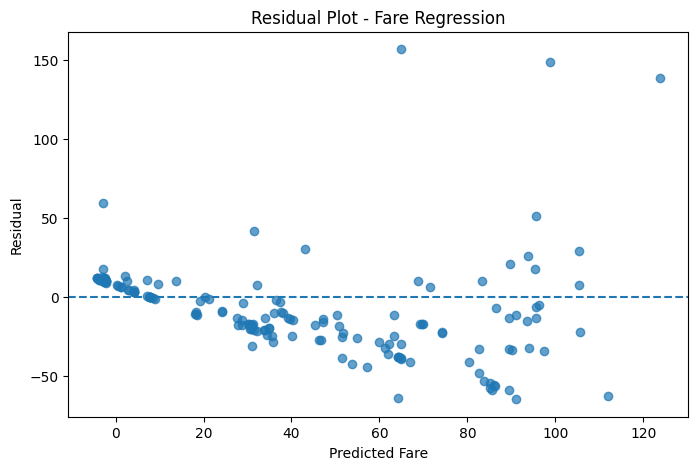

Correlation between predictions and absolute residuals: 0.548
Conclusion: The residual spread changes with the predicted fare values, suggesting heteroscedasticity.


In [20]:
residuals = (
    y_reg_test -
    reg_predictions
)


plt.figure(figsize=(8, 5))

plt.scatter(
    reg_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot - Fare Regression")

plt.show()


# Simple diagnostic:
# relationship between predicted value and
# absolute residual magnitude

hetero_corr = np.corrcoef(
    reg_predictions,
    np.abs(residuals)
)[0, 1]


print(
    "Correlation between predictions and absolute residuals:",
    round(hetero_corr, 3)
)


if abs(hetero_corr) >= 0.20:

    print(
        "Conclusion: The residual spread changes with the "
        "predicted fare values, suggesting heteroscedasticity."
    )

else:

    print(
        "Conclusion: There is no strong change in residual "
        "spread across predicted values, so strong "
        "heteroscedasticity is not evident."
    )

In [21]:
print("CLASSIFICATION MODEL COMPARISON")

classification_comparison = (
    results_df
    .set_index("Model")
    .round(4)
)

display(
    classification_comparison
)


print("\nREGRESSION MODEL METRICS")

regression_comparison = pd.DataFrame(
    {
        "Model": [
            "Multivariate Linear Regression"
        ],

        "MAE": [mae],
        "RMSE": [rmse],
        "R²": [r2],
        "Adjusted R²": [adjusted_r2]
    }
)

display(
    regression_comparison.round(4)
)

CLASSIFICATION MODEL COMPARISON


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
Decision Tree,0.7933,0.8636,0.5507,0.6726,0.8292
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300



REGRESSION MODEL METRICS


,Model,MAE,RMSE,R²,Adjusted R²
0,Multivariate Linear Regression,20.8094,30.4731,0.3999,0.3679


In [22]:
best_base_row = (
    results_df
    .sort_values(
        ["AUC", "F1"],
        ascending=False
    )
    .iloc[0]
)


print("FINAL CLASSIFIER RECOMMENDATION\n")

print(
    f"Among the three main classifiers, "
    f"{best_base_row['Model']} produced the strongest "
    f"overall result based primarily on AUC."
)

print(
    f"Its accuracy was "
    f"{best_base_row['Accuracy']:.3f}, "
    f"precision was "
    f"{best_base_row['Precision']:.3f}, "
    f"recall was "
    f"{best_base_row['Recall']:.3f}, "
    f"and F1 score was "
    f"{best_base_row['F1']:.3f}."
)

print(
    f"Its AUC was "
    f"{best_base_row['AUC']:.3f}, "
    "which reflects its ability to distinguish between "
    "survived and not-survived passengers."
)

print(
    "Therefore, this classifier would be selected from the "
    "three main models for this experiment."
)

FINAL CLASSIFIER RECOMMENDATION

Among the three main classifiers, Logistic Regression produced the strongest overall result based primarily on AUC.
Its accuracy was 0.804, precision was 0.793, recall was 0.667, and F1 score was 0.724.
Its AUC was 0.844, which reflects its ability to distinguish between survived and not-survived passengers.
Therefore, this classifier would be selected from the three main models for this experiment.


In [23]:
# Best original model
best_model_name = best_base_row["Model"]

best_pipeline = fitted_models[
    best_model_name
]

best_auc = best_base_row["AUC"]


# Compare against tuned Random Forest
if tuned_rf_metrics["AUC"] > best_auc:

    best_pipeline = best_rf_pipeline
    saved_model_name = "Tuned Random Forest"
    saved_model_auc = tuned_rf_metrics["AUC"]

else:

    saved_model_name = best_model_name
    saved_model_auc = best_auc


MODEL_PATH = (
    f"{ANALYTICS_DIR}/best_model.joblib"
)


joblib.dump(
    best_pipeline,
    MODEL_PATH
)


print(
    "Saved model:",
    saved_model_name
)

print(
    "AUC:",
    round(saved_model_auc, 4)
)

print(
    "Saved to:",
    MODEL_PATH
)

Saved model: Logistic Regression
AUC: 0.8437
Saved to: /content/drive/MyDrive/zepto-data-ai-platform/analytics/best_model.joblib


In [25]:
loaded_pipeline = joblib.load(
    MODEL_PATH
)


raw_example = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [7.25],
    "embarked": ["S"]
})


prediction = loaded_pipeline.predict(
    raw_example
)


print(
    "Prediction from reloaded pipeline:",
    prediction[0]
)


print(
    "Saved pipeline accepts raw, unprocessed input."
)

Prediction from reloaded pipeline: 0
Saved pipeline accepts raw, unprocessed input.


In [26]:
requirements = """pandas
numpy
seaborn
matplotlib
scikit-learn
imbalanced-learn
joblib
"""

with open(
    f"{ANALYTICS_DIR}/requirements.txt",
    "w"
) as f:

    f.write(requirements)


print(
    "analytics requirements.txt created"
)

analytics requirements.txt created


In [27]:
print("ANALYTICS FILES:\n")

for file in os.listdir(
    ANALYTICS_DIR
):

    print(file)

ANALYTICS FILES:

titanic.csv
titanic_cleaned.csv
01_eda.ipynb
02_modeling.ipynb
best_model.joblib
requirements.txt


In [29]:
# Calculate original missing percentages again from the saved CSV
missing_pct = (df.isnull().mean() * 100)
missing_pct = missing_pct[missing_pct > 0]

classification_md = results_df.round(4).to_markdown(index=False)
imbalance_md = imbalance_df.round(4).to_markdown(index=False)

readme = f'''# Module 2 — Analytics Pipeline

## Overview

This module performs an end-to-end analytics and machine-learning workflow
using the Titanic dataset.

The dataset was loaded exactly once using Seaborn in `01_eda.ipynb` and
immediately saved as `titanic.csv`. The modeling notebook reads this saved
CSV rather than loading the dataset again.

## Part A — Exploratory Data Analysis

### Dataset Profiling

The dataset was examined using:

- `df.info()`
- `df.describe()`
- `df.shape`

### Missing Values

Measured missing-value percentages:

{missing_pct.round(2).to_string()}

The required threshold strategy was applied:

- Under 5% missing: affected rows were dropped.
- 5%–30% missing: values were imputed.
- Very high missingness: the column was dropped when reliable imputation
  was not appropriate.

For this dataset, age was median-imputed, rows with missing embarkation
information were removed, and the deck column was dropped because of its
very high missing percentage.

### Univariate Analysis

Histograms and box plots were produced for `age` and `fare`.

Outlier counts were calculated using the IQR rule:

`Q1 - 1.5 × IQR` to `Q3 + 1.5 × IQR`.

Fare mean, median and mode were also calculated to determine the shape of
the fare distribution.

### Bivariate Analysis

Survival rates were calculated by:

- sex
- passenger class
- sex and passenger class together

The correlation matrix used exactly:

- survived
- pclass
- age
- sibsp
- parch
- fare

The derived Boolean columns `adult_male` and `alone` were intentionally
excluded.

### Multivariate Analysis

Four charts were created:

1. Survival by sex
2. Survival by passenger class
3. Survival by sex and passenger class
4. Fare distribution by survival

Each chart is accompanied by a written interpretation in `01_eda.ipynb`.

### Standardization

Age and fare were standardized using `StandardScaler`.

The transformed variables were checked to confirm approximately:

- mean = 0
- standard deviation = 1

This was only an exploratory EDA check and was not reused for model
training.

---

## Part B — Classification

The classification target is `survived`.

Features used:

- pclass
- sex
- age
- sibsp
- parch
- fare
- embarked

A stratified train/test split was performed before preprocessing.

All preprocessing is contained inside scikit-learn pipelines, ensuring
that imputation, encoding and scaling are fitted only on training data.

### Models

Three classifiers were trained:

- Logistic Regression
- Decision Tree
- Random Forest

### Classification Model Comparison

{classification_md}

Each model was evaluated using:

- Accuracy
- Precision
- Recall
- F1 score
- Confusion matrix
- ROC curve
- AUC

The Decision Tree was also visualized using `plot_tree`.

---

## Imbalance Handling

Three approaches were compared:

1. Baseline
2. `class_weight="balanced"`
3. SMOTE

SMOTE was applied only to the training data through an imbalanced-learn
pipeline.

### Imbalance Comparison

{imbalance_md}

The strategy with the strongest F1 score was considered the best balance
between precision and recall in this experiment.

---

## Random Forest Hyperparameter Tuning

`GridSearchCV` was used to tune:

- n_estimators
- max_depth
- max_features

Best parameters:

`{grid_search.best_params_}`

Best cross-validation F1:

`{grid_search.best_score_:.4f}`

OOB score:

`{best_rf_model.oob_score_:.4f}`

The Random Forest was constructed with `oob_score=True`.

---

## Regression Task

Multivariate Linear Regression was used to predict `fare`.

Results:

- MAE: {mae:.4f}
- RMSE: {rmse:.4f}
- R²: {r2:.4f}
- Adjusted R²: {adjusted_r2:.4f}

A residual plot was produced in `02_modeling.ipynb` to examine whether the
residual spread indicates heteroscedasticity.

---

## Final Classification Selection

The saved classifier is:

**{saved_model_name}**

AUC:

**{saved_model_auc:.4f}**

The classifier was selected by comparing performance metrics, particularly
AUC and F1 score.

---

## Saved Pipeline

The complete preprocessing and classification pipeline was saved as:

`best_model.joblib`

The artifact contains both preprocessing and the final estimator.

It was reloaded with `joblib.load()` and successfully produced a prediction
from raw, unprocessed passenger data.

## Files

- `01_eda.ipynb`
- `02_modeling.ipynb`
- `titanic.csv`
- `titanic_cleaned.csv`
- `best_model.joblib`
- `requirements.txt`
- `README.md`

## Running the Module

Install:

`pip install pandas numpy seaborn matplotlib scikit-learn imbalanced-learn joblib`

Run `01_eda.ipynb` first and then `02_modeling.ipynb`.
'''

with open(f"{ANALYTICS_DIR}/README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("analytics/README.md created")

analytics/README.md created
